In [ ]:
import numpy as np
import pandas as pd
import os
import random

import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pickle
import matplotlib.pyplot as plt

In [ ]:
def seed_everything(seed=100):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


learning_rate= 0.001
epochs= 25

Using device: cuda


In [ ]:
from torchvision import datasets, transforms

# Separate explicit endpoints for the original splits
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform = [transforms.ToTensor()])
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform = [transforms.ToTensor()])
# --- ADDED LINES ---
# Extracting and scaling the training features and labels
x_train = train_dataset.data.float() / 255.0
y_train = train_dataset.targets
x_test = test_dataset.data.float()/255.0
y_test = test_dataset.targets

# --- ADDED LINES FOR FLATTENING ---
# Flatten from [60000, 28, 28] to [60000, 784]
x_train = x_train.view(x_train.size(0), -1)
x_test  = x_test.view(x_test.size(0), -1)

x_test.shape

100%|██████████| 26.4M/26.4M [00:00<00:00, 117MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.45MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 64.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.6MB/s]


torch.Size([10000, 784])

In [ ]:

from torch.utils.data.dataloader import DataLoader

class data_loader(torch.utils.data.Dataset):
  def __init__(self, x_tensor, y_tensor):
    self.x= x_tensor
    self.y= y_tensor

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

#creating a train dataset object, test dataset object

train_data= data_loader(x_train, y_train)
test_data = data_loader(x_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
'''technically, we do not need to onehot encode our ydata as the loss function
CrossEntropyLoss accepts target lables encoded in class form AND onehot encoded
form. I am choosing to OneHotEncode because we may want to perform label
smoothing or other transforms later on.'''

y_train = F.one_hot(y_train, num_classes=10)
y_test  = F.one_hot(y_test, num_classes=10)

In [ ]:
class AutoEncoder(nn.Module):
  def __init__(self, input_dimension, latent_space_dim, layers_size):
    '''layer_size is an array of the number of neurons in each layer. it starts
    with the number of input neurons and ends with the number of neurons in the
    layer before the latent space. eg : [784, 192, 95] -> this creates an encoder
    that takes in 784 values and has 2 layers before latent space.'''
    super().__init__()

    #encoder arch:
    layers= []
    depth = len(layers_size)
    for i in range(depth-1):
      layers.append(nn.Linear(layers_size[i], layers_size[i+1]))
      layers.append(nn.BatchNorm1d(layers_size[i+1]))
      layers.append(nn.ReLU())

    layers.append(nn.Linear(layers_size[-1], latent_space_dim))

    self.encoder = nn.Sequential(*layers)

    #decoder architecture:
    layers= []
    layers_size = layers_size[::-1]
    layers.append(nn.Linear(latent_space_dim, layers_size[0]))

    for i in range(depth-1):
        layers.append(nn.BatchNorm1d(layers_size[i]))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(layers_size[i], layers_size[i+1]))

    layers.append(nn.Sigmoid())
    self.decoder = nn.Sequential(*layers)

  def forward(self, x):
    latent = self.encoder(x)
    reconstruction = self.decoder(latent)
    return reconstruction

In [ ]:
# HYPPERPARAMETERS:
loss_function_autoencoder = nn.MSELoss()
epochs= 30

In [ ]:
def train_model(autoencoder, train_loader, lr = learning_rate, epochs= epochs):
  '''
  this function takes in a model and trains the model and returns the epoch loss.
  '''
  #creating optimizer:
  optimizer= optim.Adam(autoencoder.parameters(), lr=0.001)
  autoencoder.to(device)
  #main training loop:
  epoch_losses = []
  for epoch in range(epochs):
    total_epoch_loss= 0
    for batch_features, batch_labels in train_loader:
      batch_features = batch_features.to(device)
      optimizer.zero_grad()
      outputs= autoencoder(batch_features)
      loss= loss_function_autoencoder(outputs, batch_features)
      total_epoch_loss+= loss.item()
      #backward pass to calculate all the gradients
      loss.backward()
      #updating params.
      optimizer.step()
    average_loss= total_epoch_loss/150
    epoch_losses.append(average_loss)

  return epoch_losses


In [ ]:
Autoencoder = AutoEncoder(784, 32, [784, 392, 196, 98])
epoch_losses = train_model(Autoencoder, train_loader)


autoencoder3 = AutoEncoder(784, 16, [784, 392, 196, 98])
epoch_losses3 = train_model(autoencoder3, train_loader)

In [ ]:

autoencoder2 = AutoEncoder(784, 32, [784, 256])
epoch_losses2 = train_model(autoencoder2, train_loader)

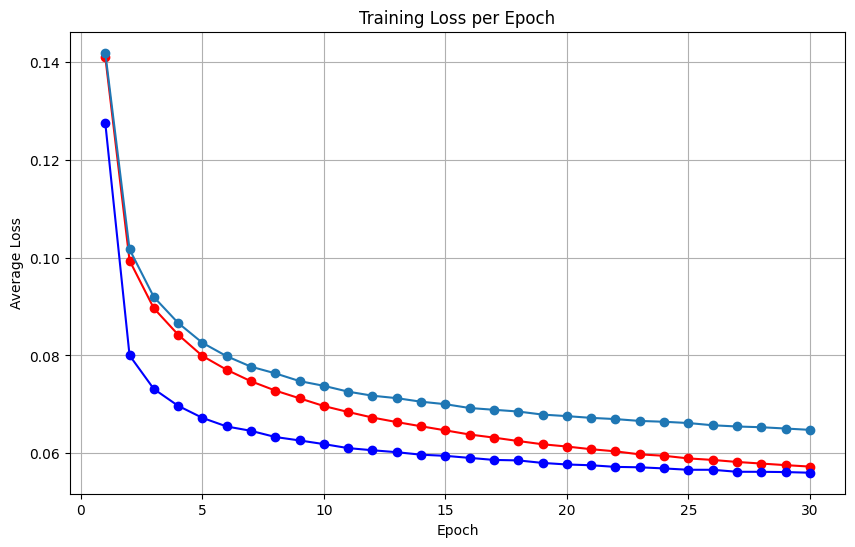

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-', color= 'red')
plt.plot(range(1, epochs + 1), epoch_losses2, marker='o', linestyle='-',color= 'blue')
plt.plot(range(1, epochs + 1), epoch_losses3, marker='o', linestyle='-')

plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.show()

In [ ]:
def test(autoencoder, test_loader):
  outputs = []
  for batch_features, batch_labels in test_loader:
    batch_features = batch_features.to(device)
    example_output = autoencoder(batch_features)
    outputs.append(example_output)
  return outputs

In [ ]:
reconstructed_outputs = test(Autoencoder, test_loader)
reconstructed_outputs2 = test(autoencoder2, test_loader)
reconstructed_outputs3 = test(autoencoder3, test_loader)

In [ ]:
def visualize_reconstructions(test_loader, reconstructed_outputs, num_images=12):
    """Displays original and reconstructed images side by side."""

    originals, _ = next(iter(test_loader))
    originals = originals[:num_images]

    if isinstance(reconstructed_outputs, list):
        reconstructed = torch.cat(reconstructed_outputs, dim=0)
    else:
        reconstructed = reconstructed_outputs
    reconstructed = reconstructed[:num_images]

    def to_np(t):
      t = t.detach().cpu()
      if t.dim() == 1:
          t = t.view(1, 28, 28)
      if t.shape[0] == 1:
          return t.squeeze(0).numpy()
      return t.permute(1, 2, 0).numpy()


    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 1.5, 3.5))
    fig.suptitle("Autoencoder Reconstructions — FashionMNIST", fontsize=13, y=1.02)
    for i in range(num_images):
        axes[0, i].imshow(to_np(originals[i]), cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=9, loc="left")

        axes[1, i].imshow(to_np(reconstructed[i]), cmap="gray")
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed", fontsize=9, loc="left")

    plt.tight_layout()
    plt.savefig("reconstructions.png", dpi=150, bbox_inches="tight")
    plt.show()

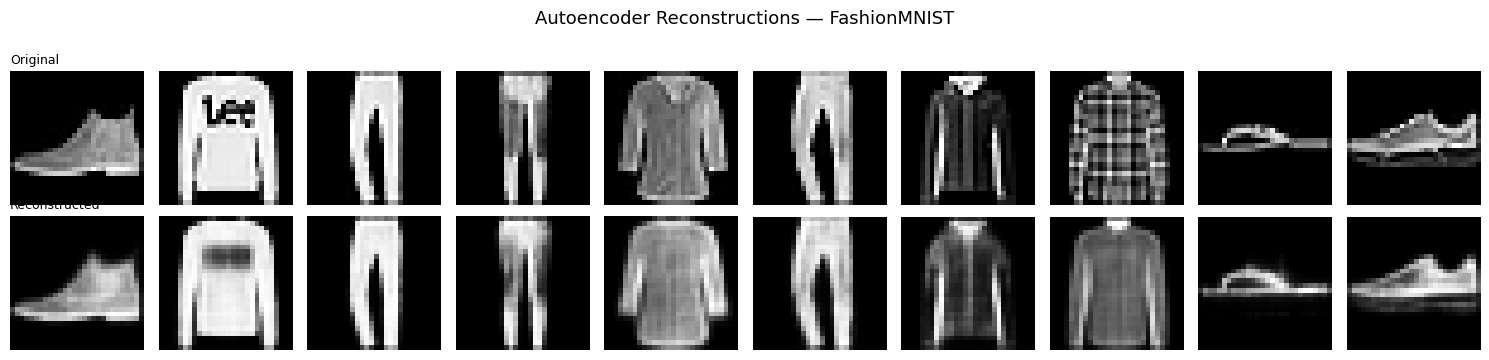

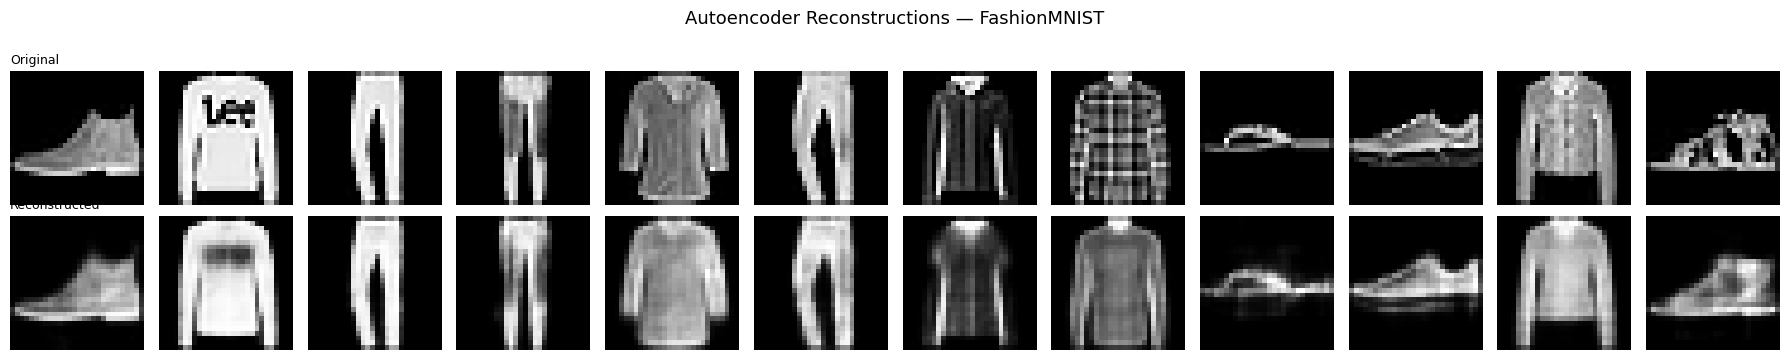

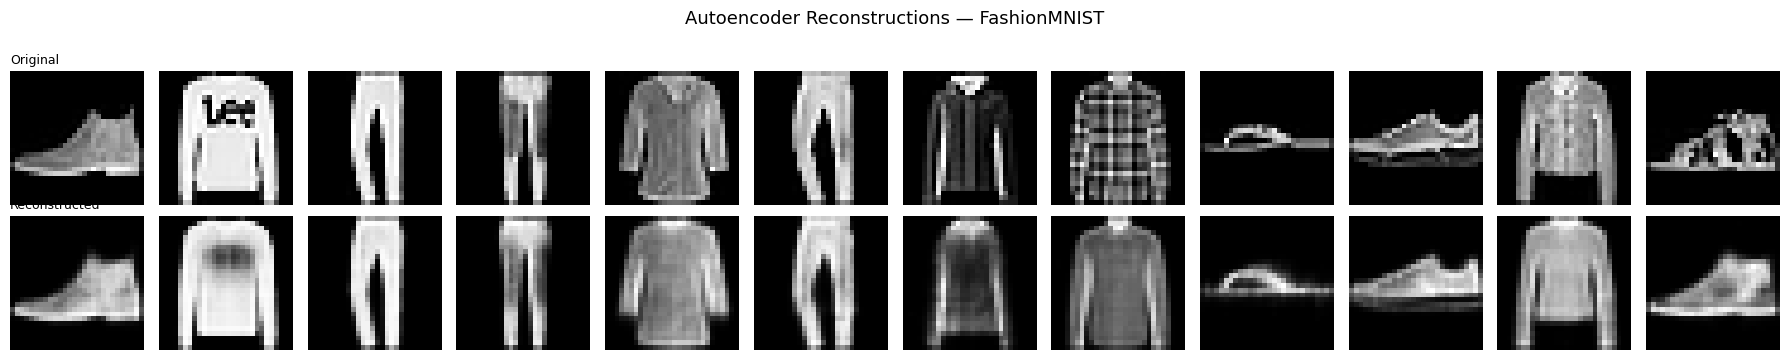

In [ ]:
visualize_reconstructions(test_loader, reconstructed_outputs, num_images=10)
visualize_reconstructions(test_loader, reconstructed_outputs2, num_images=12)
visualize_reconstructions(test_loader, reconstructed_outputs3, num_images=12)